# Audit du modele d'octroi de bourses

**But de ce carnet :** comprendre pourquoi le modele actuel donne moins de bourses aux candidats des regions eloignees, mesurer ce biais avec des chiffres, et trouver les variables qui transportent l'information regionale (les proxys).

Plan :
1. Les donnees et l'ecart entre regions
2. A cote R egale, les chances ne sont pas egales
3. Ce que le comite recompense vraiment
4. Les proxys de la region
5. Les metriques d'equite et notre choix
6. Audit du modele en production
7. Ce que change notre correction
8. Limites

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
from fairlearn.metrics import demographic_parity_difference

ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']
def preparer(df):
    df = df.copy()
    df['eloignee'] = df['region_administrative'].isin(ELOIGNEES).astype(int)
    df['groupe'] = np.where(df['eloignee'] == 1, 'Eloignee', 'Centre')
    df['log_revenu'] = np.log(df['revenu_familial_estime'])
    return df

hist = preparer(pd.read_csv('data/donnees_demandes.csv'))
cand = preparer(pd.read_csv('data/candidats_evaluation.csv'))
print(len(hist), 'dossiers historiques,', len(cand), 'candidats a evaluer')

10000 dossiers historiques, 4000 candidats a evaluer


## 1. Les donnees et l'ecart entre regions

In [2]:
hist.groupby('groupe').agg(
    candidats=('decision_octroi', 'size'),
    taux_octroi=('decision_octroi', 'mean'),
    cote_r=('cote_r_equivalent', 'mean'),
    revenu=('revenu_familial_estime', 'mean'),
    heures=('heures_travail_semaine', 'mean'),
    distance=('distance_domicile_campus_km', 'mean'),
    premiere_gen=('premiere_generation_universitaire', 'mean'),
).round(2)

,candidats,taux_octroi,cote_r,revenu,heures,distance,premiere_gen
groupe,,,,,,,
Centre,6000,0.48,27.99,76056.29,8.97,19.79,0.26
Eloignee,4000,0.27,27.33,56330.32,13.02,221.45,0.44


Le comite accorde une bourse a environ 48 % des candidats des grands centres, contre 27 % en region eloignee.
La cote R moyenne n'est que 0,7 point plus basse en region. Les candidats des regions travaillent aussi plus d'heures, ont un revenu familial plus bas et habitent beaucoup plus loin du campus.

## 2. A cote R egale, les chances ne sont pas egales

In [3]:
hist['tranche_R'] = pd.cut(hist['cote_r_equivalent'], [0, 25, 26, 27, 28, 29, 30, 31, 32, 40])
t = hist.pivot_table(index='tranche_R', columns='groupe', values='decision_octroi', aggfunc='mean').round(2)
t['ecart'] = (t['Centre'] - t['Eloignee']).round(2)
t

groupe,Centre,Eloignee,ecart
tranche_R,,,
"(0, 25]",0.00,0.00,0.00
"(25, 26]",0.05,0.01,0.04
"(26, 27]",0.16,0.04,0.12
"(27, 28]",0.32,0.10,0.22
"(28, 29]",0.59,0.26,0.33
"(29, 30]",0.85,0.57,0.28
"(30, 31]",0.94,0.78,0.16
"(31, 32]",0.99,0.92,0.07
"(32, 40]",1.00,0.99,0.01


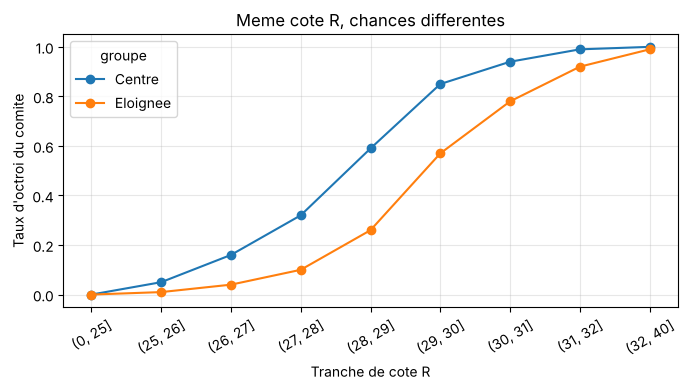

In [4]:
ax = t[['Centre', 'Eloignee']].plot(marker='o', figsize=(7, 4))
ax.set_ylabel("Taux d'octroi du comite"); ax.set_xlabel('Tranche de cote R')
ax.set_title("Meme cote R, chances differentes"); ax.grid(alpha=.3)
plt.xticks(rotation=30); plt.tight_layout(); plt.savefig('figures/meme_cote_r.png', dpi=150); plt.show()

Entre 28 et 29 de cote R, un candidat de Montreal ou de Quebec obtient la bourse 59 % du temps. Un candidat de la Gaspesie avec la meme cote l'obtient 26 % du temps.
La difference de cote R moyenne n'explique donc qu'une petite partie de l'ecart.

## 3. Ce que le comite recompense vraiment

On modelise la decision du comite avec une regression logistique. On verifie d'abord qu'un modele plus souple (foret aleatoire) ne fait pas mieux : si c'est le cas, la logistique decrit bien le comite et on peut lire ses coefficients.

In [5]:
cv = StratifiedKFold(5, shuffle=True, random_state=0)
X_lin = hist[['cote_r_equivalent', 'heures_travail_semaine', 'log_revenu', 'eloignee']]
X_all = pd.get_dummies(hist[['cote_r_equivalent', 'heures_travail_semaine', 'revenu_familial_estime',
                             'distance_domicile_campus_km', 'premiere_generation_universitaire',
                             'programme_etudes', 'code_postal_3']], columns=['programme_etudes', 'code_postal_3'])
y = hist['decision_octroi']
p_lin = cross_val_predict(LogisticRegression(C=1e4, max_iter=5000), X_lin, y, cv=cv, method='predict_proba')[:, 1]
p_rf = cross_val_predict(RandomForestClassifier(300, min_samples_leaf=20, random_state=0), X_all, y, cv=cv, method='predict_proba')[:, 1]
print(f'Logistique (4 variables) : exactitude {accuracy_score(y, p_lin > .5):.3f}, log-loss {log_loss(y, p_lin):.3f}')
print(f'Foret aleatoire (tout)   : exactitude {accuracy_score(y, p_rf > .5):.3f}, log-loss {log_loss(y, p_rf):.3f}')

Logistique (4 variables) : exactitude 0.887, log-loss 0.259
Foret aleatoire (tout)   : exactitude 0.881, log-loss 0.315


In [6]:
comite = smf.logit('decision_octroi ~ cote_r_equivalent + heures_travail_semaine + log_revenu + eloignee + premiere_generation_universitaire + C(programme_etudes)', hist).fit(disp=0)
res = pd.DataFrame({'coef': comite.params, 'IC 2,5 %': comite.conf_int()[0], 'IC 97,5 %': comite.conf_int()[1], 'p': comite.pvalues})
res.round(3)

,coef,"IC 2,5 %","IC 97,5 %",p
Intercept,-60.573,-63.663,-57.483,0.000
C(programme_etudes)[T.Genie],0.054,-0.166,0.274,0.630
C(programme_etudes)[T.Sante],0.063,-0.174,0.299,0.603
C(programme_etudes)[T.Sciences],0.022,-0.203,0.247,0.848
C(programme_etudes)[T.Sciences sociales],0.010,-0.216,0.236,0.930
cote_r_equivalent,1.384,1.325,1.443,0.000
heures_travail_semaine,0.201,0.179,0.224,0.000
log_revenu,1.779,1.601,1.958,0.000
eloignee,-1.931,-2.122,-1.740,0.000
premiere_generation_universitaire,-0.053,-0.204,0.097,0.486


In [7]:
b = comite.params
print(f"Region eloignee : -{-b['eloignee'] / b['cote_r_equivalent']:.2f} point de cote R")
print(f"Une heure de travail par semaine : +{b['heures_travail_semaine'] / b['cote_r_equivalent']:.3f} point de cote R")
print(f"Revenu familial double : +{b['log_revenu'] * np.log(2) / b['cote_r_equivalent']:.2f} point de cote R")

Region eloignee : -1.39 point de cote R
Une heure de travail par semaine : +0.146 point de cote R
Revenu familial double : +0.89 point de cote R


**Lecture :**
- Habiter en region eloignee coute environ **1,4 point de cote R**, a dossier egal. C'est la partie "inexpliquee" de l'ecart.
- Le comite donne une **prime aux familles aisees** : doubler le revenu vaut presque 0,9 point de cote R. Ce n'est pas du merite. Et comme le revenu est plus bas en region, cette prime penalise encore les regions.
- Les **heures travaillees** comptent un peu (0,145 point par heure). On les garde dans le merite : travailler en etudiant demande un effort.
- Le programme d'etudes et la 1re generation n'ont aucun effet (p > 0,5).

## 4. Les proxys de la region

Un proxy est une variable qui permet de deviner la region. Si le modele s'en sert, il peut discriminer sans jamais voir la colonne region.

In [8]:
proxys = {'code_postal_3': pd.get_dummies(hist['code_postal_3']),
          'distance_domicile_campus_km': hist[['distance_domicile_campus_km']],
          'heures_travail_semaine': hist[['heures_travail_semaine']],
          'revenu_familial_estime': hist[['revenu_familial_estime']],
          'premiere_generation_universitaire': hist[['premiere_generation_universitaire']],
          'cote_r_equivalent': hist[['cote_r_equivalent']],
          'distance + heures + revenu': hist[['distance_domicile_campus_km', 'heures_travail_semaine', 'revenu_familial_estime']]}
lignes = []
for nom, X in proxys.items():
    p = cross_val_predict(RandomForestClassifier(200, min_samples_leaf=10, random_state=0), X, hist['eloignee'], cv=cv, method='predict_proba')[:, 1]
    lignes.append({'variable': nom, 'AUC pour deviner la region': roc_auc_score(hist['eloignee'], p),
                   'exactitude': accuracy_score(hist['eloignee'], p > .5)})
tab_proxys = pd.DataFrame(lignes).sort_values('AUC pour deviner la region', ascending=False).round(3)
tab_proxys

,variable,AUC pour deviner la region,exactitude
0,code_postal_3,1.000,1.000
6,distance + heures + revenu,0.998,0.989
1,distance_domicile_campus_km,0.997,0.985
2,heures_travail_semaine,0.803,0.745
3,revenu_familial_estime,0.650,0.634
4,premiere_generation_universitaire,0.585,0.619
5,cote_r_equivalent,0.531,0.572


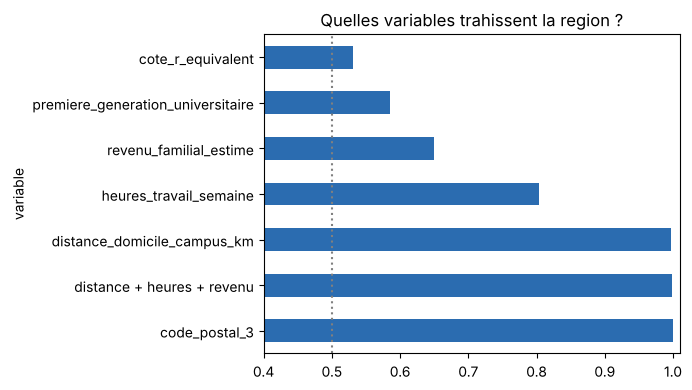

In [9]:
ax = tab_proxys.set_index('variable')['AUC pour deviner la region'].plot.barh(figsize=(7, 4), color='#2b6cb0')
ax.axvline(.5, color='grey', ls=':'); ax.set_xlim(.4, 1.01); ax.set_title('Quelles variables trahissent la region ?')
plt.tight_layout(); plt.savefig('figures/proxys.png', dpi=150); plt.show()

Le code postal donne la region a 100 %. La distance seule la donne presque parfaitement. Les heures et le revenu sont des proxys plus faibles mais reels.

**Test : supprimer la colonne region suffit-il ?**

In [10]:
train, test = train_test_split(hist, test_size=0.3, random_state=42, stratify=hist['decision_octroi'])
COLS = ['cote_r_equivalent', 'programme_etudes', 'region_administrative', 'code_postal_3', 'revenu_familial_estime',
        'heures_travail_semaine', 'distance_domicile_campus_km', 'premiere_generation_universitaire']
def essai(exclus):
    cols = [c for c in COLS if c not in exclus]
    cat = [c for c in ['programme_etudes', 'region_administrative', 'code_postal_3'] if c in cols]
    Xa = pd.get_dummies(train[cols], columns=cat); Xb = pd.get_dummies(test[cols], columns=cat).reindex(columns=Xa.columns, fill_value=0)
    p = RandomForestClassifier(300, min_samples_leaf=20, random_state=42).fit(Xa, train['decision_octroi']).predict(Xb)
    return demographic_parity_difference(test['decision_octroi'], p, sensitive_features=test['groupe'])
for exclus in [[], ['region_administrative'], ['region_administrative', 'code_postal_3'],
               ['region_administrative', 'code_postal_3', 'distance_domicile_campus_km'],
               ['region_administrative', 'code_postal_3', 'distance_domicile_campus_km', 'revenu_familial_estime']]:
    print(f"sans {exclus or 'rien'} : ecart de parite {essai(exclus):.3f}")

sans rien : ecart de parite 0.188


sans ['region_administrative'] : ecart de parite 0.180


sans ['region_administrative', 'code_postal_3'] : ecart de parite 0.173


sans ['region_administrative', 'code_postal_3', 'distance_domicile_campus_km'] : ecart de parite 0.110


sans ['region_administrative', 'code_postal_3', 'distance_domicile_campus_km', 'revenu_familial_estime'] : ecart de parite 0.072


Enlever la region puis le code postal ne change presque rien (0,188 puis 0,173). Il faut aussi enlever la distance et le revenu pour voir l'ecart baisser, et il reste quand meme a 0,07. On perd aussi de l'information utile au passage.

La raison : le modele apprend a imiter le comite, et le comite est biaise. Tant qu'on entraine sur `decision_octroi`, le biais revient par les colonnes qui restent. **Il faut changer la cible, pas seulement enlever des colonnes.**

## 5. Les metriques d'equite et notre choix

- **Parite demographique** : meme taux d'octroi dans chaque groupe.
- **Egalite des chances** : parmi les candidats qui meritent la bourse, meme taux d'octroi dans chaque groupe.

Les deux ne peuvent pas tenir en meme temps ici, parce que la cote R moyenne est un peu plus basse en region.

**Notre choix : l'egalite des chances.** Une bourse au merite doit aller aux meilleurs dossiers, peu importe d'ou ils viennent. La parite imposerait un quota regional : on refuserait des candidats de Montreal plus forts pour atteindre un chiffre. L'egalite des chances corrige l'injustice (meme merite, meme chance) sans en creer une autre.

**Le probleme :** pour mesurer l'egalite des chances, il faut savoir qui merite la bourse. `decision_octroi` ne peut pas servir, c'est la decision biaisee. On construit donc une reference de merite : la cote R plus les heures travaillees, ponderees comme le comite les pondere, sans region et sans revenu. On garde les 40 % meilleurs.

In [11]:
POIDS_H = b['heures_travail_semaine'] / b['cote_r_equivalent']
def merite(df): return df['cote_r_equivalent'] + POIDS_H * df['heures_travail_semaine']
def top40(s): return (s >= np.quantile(s, .6)).astype(int)
def audit(pred, df, ref):
    g = df['eloignee'].values; pred = np.asarray(pred)
    tpr = [pred[(ref == 1) & (g == k)].mean() for k in (0, 1)]
    return pd.Series({'taux octroi centres': pred[g == 0].mean(), 'taux octroi regions': pred[g == 1].mean(),
                      'ecart de parite': pred[g == 0].mean() - pred[g == 1].mean(),
                      'TPR centres': tpr[0], 'TPR regions': tpr[1], "ecart d'egalite des chances": tpr[0] - tpr[1]})

## 6. Audit du modele en production

In [12]:
Xa = pd.get_dummies(train[COLS], columns=['programme_etudes', 'region_administrative', 'code_postal_3'])
Xb = pd.get_dummies(test[COLS], columns=['programme_etudes', 'region_administrative', 'code_postal_3']).reindex(columns=Xa.columns, fill_value=0)
prod = RandomForestClassifier(300, min_samples_leaf=20, random_state=42).fit(Xa, train['decision_octroi'])
ref_test = top40(merite(test)).values
pd.DataFrame({'comite (historique)': audit(test['decision_octroi'], test, ref_test),
              'modele en production': audit(prod.predict(Xb), test, ref_test)}).round(3)

,comite (historique),modele en production
taux octroi centres,0.484,0.459
taux octroi regions,0.277,0.271
ecart de parite,0.207,0.188
TPR centres,0.934,0.993
TPR regions,0.646,0.675
ecart d'egalite des chances,0.287,0.318


Parmi les candidats qui meritent la bourse, ceux des centres l'obtiennent bien plus souvent que ceux des regions. L'ecart d'egalite des chances du modele en production est d'environ 0,3. L'enonce donne 0,270 avec la reference officielle, c'est le meme ordre de grandeur.

Le notebook de depart calcule un "taux de vrais positifs" par rapport a `decision_octroi`. Ce chiffre montre seulement que le modele copie bien le comite, pas qu'il est juste.

## 7. Ce que change notre correction

In [13]:
corrige = top40(merite(test)).values
pd.DataFrame({'modele en production': audit(prod.predict(Xb), test, ref_test),
              'modele corrige': audit(corrige, test, ref_test)}).round(3)

,modele en production,modele corrige
taux octroi centres,0.459,0.399
taux octroi regions,0.271,0.402
ecart de parite,0.188,-0.003
TPR centres,0.993,1.000
TPR regions,0.675,1.000
ecart d'egalite des chances,0.318,0.000


In [14]:
pred = pd.read_csv('predictions.csv')
print('Taux d\'octroi global :', pred['decision_octroi'].mean())
pred.assign(region=cand['region_administrative']).groupby('region')['decision_octroi'].mean().round(3)

Taux d'octroi global : 0.4


region
Bas-Saint-Laurent                0.383
Capitale-Nationale               0.397
Cote-Nord                        0.397
Gaspesie-Iles-de-la-Madeleine    0.415
Montreal                         0.402
Name: decision_octroi, dtype: float64

Sur les 4000 candidats, notre modele donne entre 38 % et 42 % de bourses dans chaque region. Le petit ecart restant vient seulement des differences reelles de cote R et d'heures travaillees.

**Validation externe.** La plateforme donne un score indicatif contre l'etalon de reference. Notre modele obtient **94,63 % d'exactitude et 94,40 % de F1 macro**. La copie du comite sans la region obtient 92,5 %, ce qui confirme que la prime au revenu est un biais et non du merite. Le detail de nos essais est dans `experiences/scores_indicatifs.csv`.

## 8. Limites

- **La reference de merite est un choix.** On suppose que le merite, c'est la cote R plus l'effort de travail. Un autre comite pourrait vouloir tenir compte du besoin financier. Ce choix doit etre valide par des humains.
- **La mesure d'egalite des chances depend de cette reference.** Elle vaut 0 pour notre modele presque par construction. Le score externe (94,6 %) est notre vrai controle.
- **Donnees synthetiques.** Les variables sont presque independantes entre elles. Dans la vraie vie, la cote R elle-meme peut porter un biais (ecoles moins financees en region).
- **Petits groupes.** La Cote-Nord compte environ 500 candidats : les taux par region bougent de quelques points d'une annee a l'autre par simple hasard.
- **Deux groupes seulement.** On a regroupe les regions en centres et eloignees. Il faut aussi suivre chaque region separement.